In [2]:
# Import required packages

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import os

# Create directory for data
if not os.path.exists('mitdb'):
    os.makedirs('mitdb')

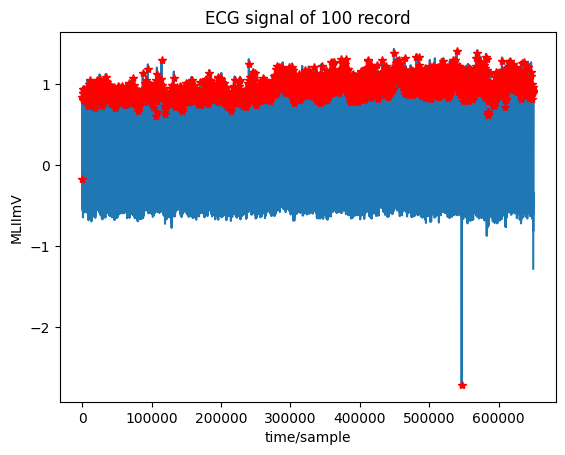

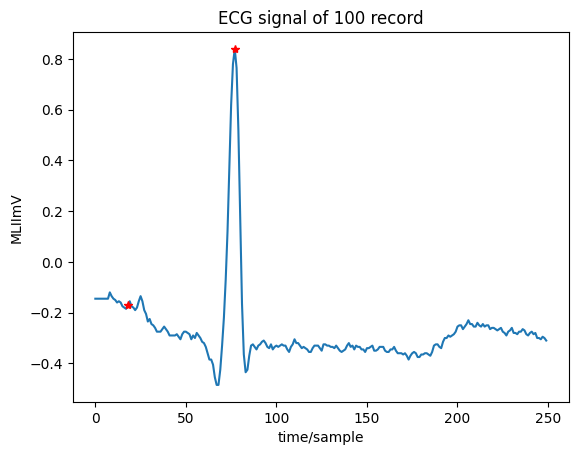

Sampling Frequency: 360 Hz
Annotation locations: [    77    370    662 ... 649484 649734 649991]
Annotations: {'+', 'A', 'V', 'N'}


In [94]:
# Read a sample record
base_path= "mit-bih-arrhythmia-database-1.0.0"
record = wfdb.rdrecord('mit-bih-arrhythmia-database-1.0.0/100',channels=[0])
annotation = wfdb.rdann('mit-bih-arrhythmia-database-1.0.0/100', 'atr')

# Get signal and metadata
fs = record.fs  # Sampling frequency
ecg_signal = record.p_signal[:, 0]  # MLII lead
ann_samples = annotation.sample  # Annotation locations
ann_samples=ann_samples[1:]  # Remove the first annotation (not a beat)
ann_symbols = annotation.symbol  # Annotation symbols

# Plot the ECG signal
wfdb.plot_wfdb(record=record, annotation=annotation, title="ECG signal of 100 record",time_units='samples')

# Plot the first 5 seconds of the ECG signal
tr_record= wfdb.rdrecord('mit-bih-arrhythmia-database-1.0.0/100', sampto=250, channels=[0])
tr_annotation = wfdb.rdann('mit-bih-arrhythmia-database-1.0.0/100', 'atr', sampto=250)
wfdb.plot_wfdb(record=tr_record, annotation=tr_annotation, title="ECG signal of 100 record", time_units='samples')
# Print annotation information
print(f"Sampling Frequency: {fs} Hz")
print(f"Annotation locations: {ann_samples}")
print(f"Annotations: {set(ann_symbols)}")

In [34]:
def preprocess_ecg(ecg_signal, fs):
    """
    Preprocess ECG signal with filtering and normalization
    """
    # 1. Bandpass filter (0.5-40 Hz)
    nyquist = 0.5 * fs
    low = 0.5 / nyquist
    high = 15.0 / nyquist
    b, a = signal.butter(4, [low, high], btype='band')
    filtered = signal.filtfilt(b, a, ecg_signal)
    
    # 2. Notch filter (50/60 Hz)
    notch_freq = 50.0  # or 60.0 depending on your region
    Q = 35.0
    b, a = signal.iirnotch(notch_freq/nyquist, Q)
    filtered = signal.filtfilt(b, a, filtered)
    
    # 3. Normalization
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    
    return normalized

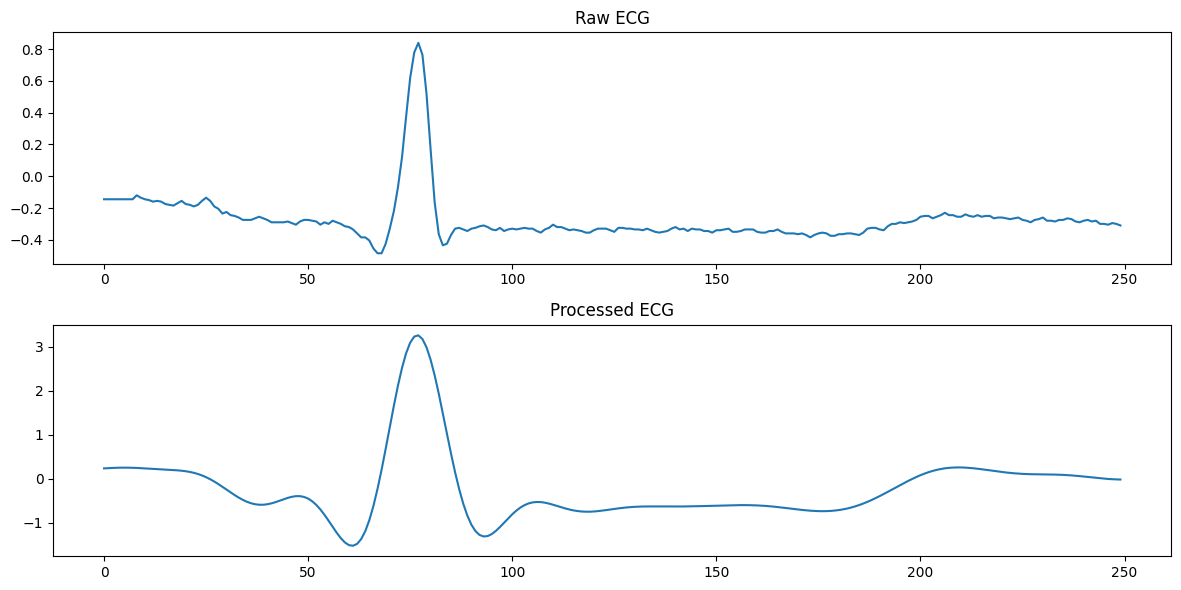

In [86]:
# Apply preprocessing
processed_ecg = preprocess_ecg(ecg_signal, fs)

# Plot before/after
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(ecg_signal[0:250])
plt.title('Raw ECG')
plt.subplot(2, 1, 2)
plt.plot(processed_ecg[0:250])
plt.title('Processed ECG')
plt.tight_layout()
plt.show()

Extracted 2271 beats [[-0.029356   -0.01871596 -0.00874404 ...  0.1710701   0.17672474
   0.18243213]
 [-0.04250609 -0.04404113 -0.04606637 ...  0.11514198  0.10054799
   0.08454224]
 [-0.19143388 -0.19749782 -0.20133249 ...  0.21423971  0.20293074
   0.19089826]
 ...
 [-0.67736515 -0.68402137 -0.68756614 ...  0.43527678  0.43717499
   0.4373885 ]
 [ 0.28953     0.2829541   0.27809645 ...  1.25951789  1.2419406
   1.22304277]
 [ 0.78845821  0.76836527  0.75072433 ... -2.57264081 -2.56114463
  -2.55369568]]


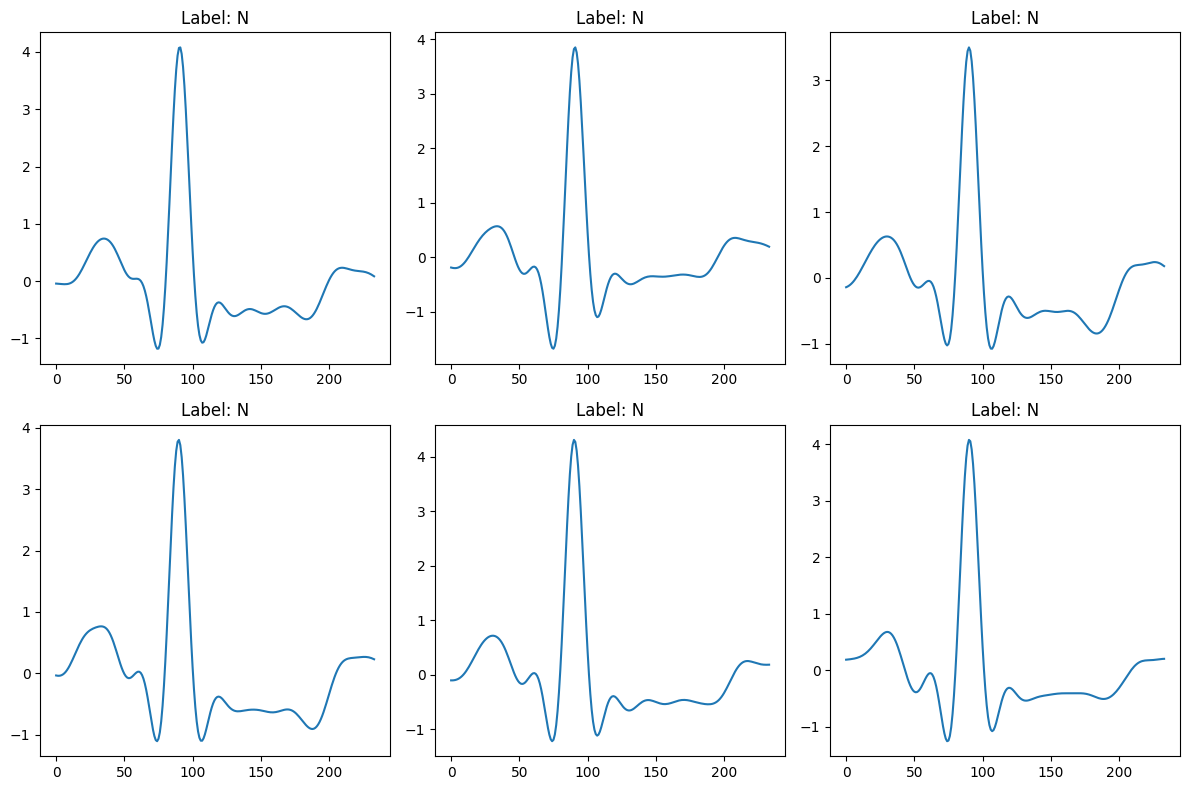

In [112]:
def extract_beats(signal, ann_samples, ann_symbols, fs, before=0.25, after=0.4):
    """
    Extract beats centered at R-peaks
    before: seconds before R-peak
    after: seconds after R-peak
    """
    beats = []
    labels = []
    before_samples = int(before * fs)
    after_samples = int(after * fs)
    
    for i, (sample, symbol) in enumerate(zip(ann_samples, ann_symbols)):
        # Only consider normal and some abnormal beats for this example
        start = sample - before_samples
        end = sample + after_samples
        
        # Check boundaries
        if start >= 0 and end < len(signal):
            beat = signal[start:end]
            beats.append(beat)
            labels.append(symbol)
    
    return np.array(beats), np.array(labels)

# Extract beats
beats, labels = extract_beats(processed_ecg, ann_samples, ann_symbols, fs)
print(f"Extracted {len(beats)} beats {beats}")
beats = beats[1:]  # Remove the first beat (not a normal beat)
# Plot some example beats
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.plot(beats[i])
    plt.title(f'Label: {labels[i]}')
plt.tight_layout()
plt.show()

In [125]:
def ricker_wavelet(points, a):
    A = 2 / (np.sqrt(3 * a) * (np.pi ** 0.25))
    wsq = a ** 2
    t = np.linspace(-points / 2, points / 2, points)
    mod = 1 - (t ** 2) / wsq
    gauss = np.exp(-(t ** 2) / (2 * wsq))
    return A * mod * gauss

In [132]:
from scipy.signal import convolve  # Correct wavelet import

def extract_features(beats, fs):
    features = []
    for beat in beats:
        # Basic statistical features
        beat_features = [
            np.mean(beat),
            np.std(beat),
            np.min(beat),
            np.max(beat)
        ]
        
        # Wavelet features (if CWT works)
        # Choose scale 'a' based on sampling rate (fs)
        wavelet = ricker_wavelet(points=len(beat), a=4.0)

        # Convolve beat with Ricker wavelet
        conv_result = convolve(beat, wavelet, mode='same')

        # Extract some features
        energy = np.sum(conv_result ** 2)
        max_val = np.max(np.abs(conv_result))
        mean_val = np.mean(conv_result)

        beat_features.append(energy)
        beat_features.append(max_val)
        beat_features.append(mean_val)

        # QRS features
        middle = len(beat) // 2
        qrs = beat[middle-10:middle+10]
        beat_features.append(np.ptp(qrs))  # Peak-to-peak amplitude
        beat_features.append(len(qrs)/fs)  # Duration
        
        features.append(beat_features)
    
    return np.array(features)

# Extract features
X = extract_features(beats, fs)
y = labels

print(f"Extracted {X.shape[0]} beats with {X.shape[1]} features each")
print(f"Feature matrix shape: {X}")

Extracted 2270 beats with 9 features each
Feature matrix shape: [[ 3.94445013e-02  9.50338189e-01 -1.17922667e+00 ...  2.78921686e-03
   7.03651936e-01  5.55555556e-02]
 [ 1.87240197e-02  8.97373031e-01 -1.68048719e+00 ...  1.54839723e-03
   7.97232770e-01  5.55555556e-02]
 [-3.25112673e-02  8.48160667e-01 -1.07610933e+00 ...  4.43718091e-03
   7.93463635e-01  5.55555556e-02]
 ...
 [-4.11319481e-01  9.01463734e-01 -2.00049978e+00 ... -7.44975336e-03
   8.80493505e-01  5.55555556e-02]
 [ 1.22734526e+00  9.23307551e-01 -2.80979655e-01 ...  4.66786755e-02
   9.23723563e-01  5.55555556e-02]
 [-1.48016219e+00  1.82351093e+00 -3.72086069e+00 ... -5.51539666e-02
   4.85265688e-01  5.55555556e-02]]


In [134]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ensure X and y have the same number of samples
min_samples = min(len(X), len(y))
X = X[:min_samples]
y = y[:min_samples]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale'),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Classification report
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


=== Random Forest ===


ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter